# DreaMS embeddings: PCA vs UMAP

DreaMS turns each MS/MS spectrum into a 1024-number vector of length 1. This notebook asks what that space looks like, and how much of it survives when we reduce it to a few dimensions with **PCA** (linear, keeps large-scale variance) or **UMAP** (non-linear, keeps neighbourhoods).

0. Load the embeddings and their metadata
1. Shared tools: distances and plot helpers
2. Distances in the full 1024-d space (the reference)
3. Reducing dimensions: PCA vs UMAP, scored against the number of dimensions
4. 2D maps, PCA and UMAP side by side
5. Distances after reduction, PCA and UMAP side by side
6. The isomer test: can DreaMS tell a molecule from same-formula alternatives?

The embeddings cover 121k train spectra: the candidates of 200 validation molecules (see `baseline.ipynb`), so masses cluster around those molecules.

## 0. Load

Load the embeddings and attach each spectrum's metadata. Row `i` of `embeddings` matches row `i` of `metadata`.

In [3]:
import os

import numpy as np
import polars as pl

DATA_DIR = "/Volumes/HDLAUDICINA/enveda-CASMI26-molecule-id-mass-spectra/data/enveda-CASMI26-molecule-id-mass-spectra" #"data/enveda-CASMI26-molecule-id-mass-spectra"
TRAIN_PATH = os.path.join(DATA_DIR, "train.parquet")
EMBEDDINGS_PATH = "/Volumes/HDLAUDICINA/enveda-CASMI26-molecule-id-mass-spectra/dreaMS/dreams_cache/embeddings.npz" #"dreams_cache/embeddings.npz"

# Embeddings computed by embed_dreams.py: one 1024-number vector per train spectrum
data = np.load(EMBEDDINGS_PATH)
row_ids = data["row_ids"]
embeddings = data["embeddings"]
print(embeddings.shape)

# Remember the position of each embedding, to put the metadata in the same order
order = pl.DataFrame({
    "row_id": row_ids.astype(np.uint32),
    "position": np.arange(len(row_ids)),
})

# Metadata of those spectra, without the peak lists (they are heavy)
metadata = (
    pl.scan_parquet(TRAIN_PATH)
    .with_row_index("row_id")
    .filter(pl.col("row_id").is_in(row_ids.tolist()))
    .select("row_id", "inchikey14", "molecular_formula", "adduct", "collision_energy_orig",
            "collision_energy_ev", "ionization_mode", "ingest_lib", "precursor_mz")
    .collect()
)
metadata = order.join(metadata, on="row_id", how="left").sort("position")

# Readable energy label from the cleaned energies: "20", "40", "20,40,60" (null when unknown).
# collision_energy_orig is the raw instrument text, with a minus sign in negative mode
energy_values = pl.col("collision_energy_ev").list.eval(pl.element().cast(pl.Int64).cast(pl.String))
metadata = metadata.with_columns(energy_label=energy_values.list.join(","))

# Checks: one metadata row per embedding, in the same order
assert metadata.height == len(embeddings)
assert (metadata["row_id"].to_numpy() == row_ids).all()

# Embeddings are unit length, so the cosine of two spectra is just their dot product
print(np.linalg.norm(embeddings[:5], axis=1))
metadata.head()

(121279, 1024)
[1. 1. 1. 1. 1.]


row_id,position,inchikey14,molecular_formula,adduct,collision_energy_orig,collision_energy_ev,ionization_mode,ingest_lib,precursor_mz,energy_label
u32,i64,str,str,str,str,list[f64],str,str,f64,str
107,0,"""AZEGJHGXTSUPPG""","""C15H18N2O3""","""[M+H]+""",null,null,"""positive""","""drug_plus""",275.139,null
127,1,"""BEZZFPOZAYTVHN""","""C15H13N3O3S""","""[M+H]+""",null,null,"""positive""","""drug_plus""",316.075,null
158,2,"""BLJRIMJGRPQVNF""","""C13H24N4O3S""","""[M+H]+""",null,null,"""positive""","""drug_plus""",317.1642,null
207,3,"""BWWVAEOLVKTZFQ""","""C15H23N3O3S""","""[M+H]+""",null,null,"""positive""","""drug_plus""",326.1533,null
242,4,"""CEQFOVLGLXCDCX""","""C15H15N3O2""","""[M+H]+""",null,null,"""positive""","""drug_plus""",270.1237,null


## 1. Shared tools

Two true metrics are used throughout (cosine distance is not one: it breaks the triangle inequality):
- **Euclidean distance**: straight-line distance between two points.
- **Angular distance**: the angle between two vectors, divided by π, so 0 = same direction, 0.5 = perpendicular, 1 = opposite.

For unit vectors both follow from the cosine similarity `s` (the dot product): Euclidean = √(2 − 2s), angular = arccos(s) / π.

In [4]:
import matplotlib.pyplot as plt
import umap
from matplotlib.lines import Line2D
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

rng = np.random.default_rng(1)

# Set to True to also save every figure as a PDF in FIGURES_DIR
SAVE_FIGURES = False
FIGURES_DIR = "figures"

# Standard matplotlib palettes: tab10 for categories, viridis for mass.
# tab10's grey is left out, because grey means "other" here
CATEGORY_COLORS = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple",
                   "tab:brown", "tab:pink", "tab:olive", "tab:cyan"]
OTHER_COLOR = "lightgrey"
MASS_COLORMAP = "viridis"


def save_figure(fig, name):
    if SAVE_FIGURES:
        os.makedirs(FIGURES_DIR, exist_ok=True)
        fig.savefig(os.path.join(FIGURES_DIR, name + ".pdf"), bbox_inches="tight")


# --- Distances from cosine similarities (unit vectors only) ---

def euclidean_distance(similarities):
    """Straight-line distance between unit vectors, from their cosine similarity: 0 to 2."""
    # clip: rounding can push a similarity slightly above 1, which would give a NaN
    return np.sqrt(np.clip(2 - 2 * similarities, 0, None))


def angular_distance(similarities):
    """Angle between unit vectors, scaled to 0 (same direction) to 1 (opposite)."""
    return np.arccos(np.clip(similarities, -1, 1)) / np.pi


# --- Distances between pairs of points, from their coordinates (any space) ---

def euclidean_between(coords, first, second):
    """Euclidean distance between coords[first[k]] and coords[second[k]], for every k."""
    return np.linalg.norm(coords[first] - coords[second], axis=1)


def angular_between(coords, first, second):
    """Angle between the vectors coords[first[k]] and coords[second[k]], measured from the origin."""
    a = coords[first]
    b = coords[second]
    cosines = np.sum(a * b, axis=1) / (np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1))
    return angular_distance(cosines)


# --- Plot helpers ---

def plot_pair_distances(ax, same_polarity, opposite_polarity, random_pairs, bins, xlabel, title, legend=False):
    """The three distance distributions used throughout, on one axis."""
    ax.hist(same_polarity, bins=bins, density=True, histtype="step", linewidth=2,
            color="blue", label="same mol, same polarity")
    ax.hist(opposite_polarity, bins=bins, density=True, histtype="step", linewidth=2,
            color="red", label="same mol, opposite polarity")
    ax.hist(random_pairs, bins=bins, density=True, histtype="step", linewidth=2,
            color="orange", label="rand mol")
    ax.set_xlim(bins[0], bins[-1])
    ax.set_xlabel(xlabel)
    ax.set_ylabel("density")
    ax.set_title(title)
    if legend:
        ax.legend(frameon=False, loc="upper left")


def top_categories(values, max_categories=7):
    """Keep the most frequent values; the rest become 'other' and missing values 'unknown'."""
    values = values.fill_null("unknown")
    top = values.value_counts(sort=True)[values.name].head(max_categories).to_list()
    labels = []
    for value in values:
        if value in top:
            labels.append(value)
        else:
            labels.append("other")
    return labels, top


def scatter_categories(ax, coords, values, title, draw_order):
    """2D scatter coloured by a categorical column, with a legend."""
    labels, categories = top_categories(values)
    color_of = {"other": OTHER_COLOR}
    for index, category in enumerate(categories):
        color_of[category] = CATEGORY_COLORS[index]
    point_colors = np.array([color_of[label] for label in labels])

    ax.scatter(coords[draw_order, 0], coords[draw_order, 1], c=point_colors[draw_order], s=2, alpha=0.5, linewidths=0)

    legend_entries = categories
    if "other" in labels:
        legend_entries = categories + ["other"]
    handles = []
    for category in legend_entries:
        handles.append(Line2D([], [], marker="o", linestyle="", color=color_of[category], label=category))
    ax.legend(handles=handles, loc="best", fontsize=7, frameon=False, markerscale=0.8)
    ax.set_title(title, loc="left")


def scatter_mass(ax, coords, masses, title, draw_order):
    """2D scatter coloured by precursor m/z."""
    # Clip the colour scale to the bulk of the masses, so a few outliers don't wash out the rest
    low, high = np.percentile(masses, [2, 98])
    points = ax.scatter(coords[draw_order, 0], coords[draw_order, 1], c=masses[draw_order],
                        cmap=MASS_COLORMAP, vmin=low, vmax=high, s=2, alpha=0.8, linewidths=0)
    plt.colorbar(points, ax=ax, label="precursor m/z")
    ax.set_title(title, loc="left")


def clean_map_axis(ax, axis_name):
    """Map coordinates have no unit: hide the ticks, keep the axis names."""
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel(f"{axis_name} 1")
    ax.set_ylabel(f"{axis_name} 2")
    ax.spines[["top", "right"]].set_visible(False)

/Users/corentin_laudicina/Desktop/FILES/PROJECTS/Enveda CASMI 2026/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Distances in the full 1024-d space

The reference before any reduction. For every molecule with more than one spectrum, all pairs of its spectra, split by polarity; and random pairs of spectra from different molecules.

20454 molecules with more than one spectrum


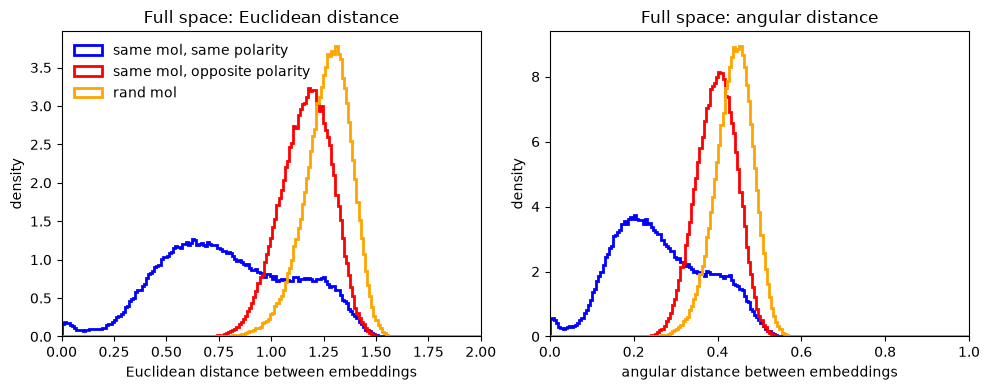

In [ ]:
MAX_SPECTRA_PER_MOLECULE = 100  # a few molecules have hundreds of replicate spectra
N_RANDOM_PAIRS = 200_000

# Positions of the spectra of each molecule that has more than one spectrum
molecule_groups = (
    metadata
    .group_by("inchikey14")
    .agg(pl.col("position"))
    .filter(pl.col("position").list.len() > 1)
)
print(molecule_groups.height, "molecules with more than one spectrum")

# Cosine similarity between every pair of spectra of the same molecule, split by polarity
# (embeddings are unit length, so the cosine similarity is the dot product)
polarities = metadata["ionization_mode"].to_numpy()
keys = metadata["inchikey14"].to_numpy()
same_polarity_similarities = []
opposite_polarity_similarities = []
for positions in molecule_groups["position"]:
    positions = positions.to_numpy()
    if len(positions) > MAX_SPECTRA_PER_MOLECULE:
        positions = rng.choice(positions, size=MAX_SPECTRA_PER_MOLECULE, replace=False)
    group_embeddings = embeddings[positions]
    similarities = group_embeddings @ group_embeddings.T

    # Each pair once, no self-pairs
    first_in_pair, second_in_pair = np.triu_indices(len(positions), k=1)
    pair_similarities = similarities[first_in_pair, second_in_pair]
    same_polarity = polarities[positions[first_in_pair]] == polarities[positions[second_in_pair]]
    same_polarity_similarities.append(pair_similarities[same_polarity])
    opposite_polarity_similarities.append(pair_similarities[~same_polarity])
same_polarity_similarities = np.concatenate(same_polarity_similarities)
opposite_polarity_similarities = np.concatenate(opposite_polarity_similarities)

# Reference: random pairs of spectra from different molecules
random_first = rng.integers(0, len(embeddings), N_RANDOM_PAIRS)
random_second = rng.integers(0, len(embeddings), N_RANDOM_PAIRS)
different_molecules = keys[random_first] != keys[random_second]
random_first = random_first[different_molecules]
random_second = random_second[different_molecules]
random_similarities = np.sum(embeddings[random_first] * embeddings[random_second], axis=1)

fig, (ax_euclidean, ax_angular) = plt.subplots(1, 2, figsize=(10, 4))

plot_pair_distances(
    ax_euclidean,
    euclidean_distance(same_polarity_similarities),
    euclidean_distance(opposite_polarity_similarities),
    euclidean_distance(random_similarities),
    bins=np.linspace(0, 2, 200),
    xlabel="Euclidean distance between embeddings",
    legend=True,
)
plot_pair_distances(
    ax_angular,
    angular_distance(same_polarity_similarities),
    angular_distance(opposite_polarity_similarities),
    angular_distance(random_similarities),
    bins=np.linspace(0, 1, 200),
    xlabel="angular distance between embeddings",
)

fig.tight_layout()
save_figure(fig, "full_space_distances")
plt.show()

## 3. Reducing dimensions: PCA vs UMAP

**How many dimensions matter?** PCA answers with its cumulative explained variance. UMAP has no equivalent: it does not decompose the variance, it only tries to keep each point's neighbours close.

50% of the variance: 20 components
90% of the variance: 211 components


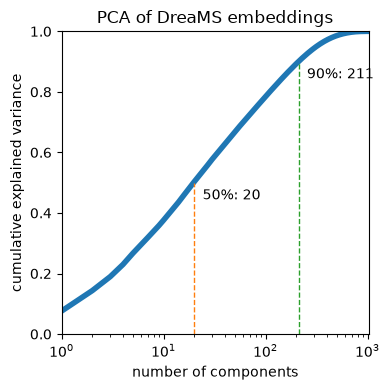

In [ ]:
# A random subsample is enough to estimate the variance spectrum
N_SAMPLE = 25_000
sample_positions = rng.choice(len(embeddings), size=N_SAMPLE, replace=False)
sample = embeddings[sample_positions]

# Keep every component, to see the full curve (PCA centres the data itself)
pca = PCA()
pca.fit(sample)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Smallest number of components reaching each share of the variance
thresholds = [0.5, 0.9]
components_needed = {}
for threshold in thresholds:
    components_needed[threshold] = int(np.searchsorted(cumulative_variance, threshold) + 1)
    print(f"{threshold:.0%} of the variance: {components_needed[threshold]} components")

# Cumulative explained variance, log x-axis to show both the first few and all 1024 components
fig, ax = plt.subplots(figsize=(4, 4))
component_numbers = np.arange(1, len(cumulative_variance) + 1)
ax.plot(component_numbers, cumulative_variance, linewidth=4)
for threshold in thresholds:
    n = components_needed[threshold]
    ax.plot([n, n], [0, threshold], linestyle="--", linewidth=1)
    ax.annotate(f"{threshold:.0%}: {n}", (n, threshold), xytext=(6, -12), textcoords="offset points")
ax.set_xscale("log")
ax.set_xlim(1, len(cumulative_variance))
ax.set_ylim(0, 1.0)
ax.set_xlabel("number of components")
ax.set_ylabel("cumulative explained variance")
ax.set_title("PCA of DreaMS embeddings")
fig.tight_layout()
save_figure(fig, "pca_cumulative_variance")
plt.show()

To compare PCA and UMAP, we use scores defined for both, against the number of output dimensions:
- **Local structure**: share of each spectrum's 15 nearest neighbours in the full space (cosine) that are still among its 15 nearest after reduction.
- **Global structure**: rank (Spearman) correlation between original and reduced distances of random pairs.
- **Same molecule**: share of spectra whose nearest neighbour is a spectrum of the same molecule. The dashed line is the full space.

The sample is ~10k spectra from whole molecules (all their spectra, at most 20), so that most spectra have a same-molecule partner. Both methods are fitted on this sample; UMAP works on the raw embeddings with the cosine metric. The reduced coordinates are kept for section 5.

In [ ]:
N_SPECTRA = 10_000
MAX_SPECTRA_PER_COMPARED_MOLECULE = 20
N_NEIGHBOURS = 15
N_CORRELATION_PAIRS = 50_000
DIMENSIONS = [2, 5, 10, 20, 50]

# Sample whole molecules (all their spectra, capped), so most spectra have a same-molecule partner
shuffled_molecules = molecule_groups.sample(fraction=1.0, shuffle=True, seed=0)
compare_positions = []
for positions in shuffled_molecules["position"]:
    compare_positions.extend(positions.to_list()[:MAX_SPECTRA_PER_COMPARED_MOLECULE])
    if len(compare_positions) >= N_SPECTRA:
        break
compare_positions = np.array(compare_positions)
compare_embeddings = embeddings[compare_positions]
compare_keys = keys[compare_positions]
print(len(compare_positions), "spectra from", len(set(compare_keys)), "molecules")


def nearest_neighbours(coords, metric):
    """Indices of each point's N_NEIGHBOURS nearest other points."""
    finder = NearestNeighbors(n_neighbors=N_NEIGHBOURS + 1, metric=metric).fit(coords)
    neighbours = finder.kneighbors(coords, return_distance=False)
    return neighbours[:, 1:]  # drop the point itself


def neighbour_recall(neighbours, true_neighbours):
    """Average share of each point's true neighbours that are still among its neighbours."""
    shares = []
    for found, true in zip(neighbours, true_neighbours):
        shares.append(len(set(found) & set(true)) / N_NEIGHBOURS)
    return float(np.mean(shares))


def same_molecule_rate(neighbours):
    """Share of spectra whose single nearest neighbour is a spectrum of the same molecule."""
    nearest = neighbours[:, 0]
    return float(np.mean(compare_keys[nearest] == compare_keys))


# Random pairs, used to check whether distances keep their order
correlation_first = rng.integers(0, len(compare_positions), N_CORRELATION_PAIRS)
correlation_second = rng.integers(0, len(compare_positions), N_CORRELATION_PAIRS)
original_distances = angular_between(compare_embeddings, correlation_first, correlation_second)


def distance_correlation(coords):
    """Spearman correlation between original and reduced distances of the random pairs."""
    reduced_distances = euclidean_between(coords, correlation_first, correlation_second)
    return float(spearmanr(original_distances, reduced_distances).statistic)


# Reference: the full space with the cosine metric
true_neighbours = nearest_neighbours(compare_embeddings, "cosine")
full_space_same_molecule = same_molecule_rate(true_neighbours)

# Reduce with both methods for each number of dimensions, score, and keep the coordinates
compare_pca = PCA().fit(compare_embeddings)
compare_pca_coords = compare_pca.transform(compare_embeddings)
reduced_coords = {"PCA": {}, "UMAP": {}}
scores = {"PCA": {"recall": [], "correlation": [], "same_molecule": []},
          "UMAP": {"recall": [], "correlation": [], "same_molecule": []}}
for n_dimensions in DIMENSIONS:
    reduced_coords["PCA"][n_dimensions] = compare_pca_coords[:, :n_dimensions]
    reduced_coords["UMAP"][n_dimensions] = umap.UMAP(
        n_components=n_dimensions, n_neighbors=15, min_dist=0.1, metric="cosine", random_state=0
    ).fit_transform(compare_embeddings)

    for method in ["PCA", "UMAP"]:
        coords = reduced_coords[method][n_dimensions]
        neighbours = nearest_neighbours(coords, "euclidean")
        scores[method]["recall"].append(neighbour_recall(neighbours, true_neighbours))
        scores[method]["correlation"].append(distance_correlation(coords))
        scores[method]["same_molecule"].append(same_molecule_rate(neighbours))
    print(f"{n_dimensions:>3} dimensions done")

10002 spectra from 1816 molecules


/Users/corentin_laudicina/Desktop/FILES/PROJECTS/Enveda CASMI 2026/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  2 dimensions done


/Users/corentin_laudicina/Desktop/FILES/PROJECTS/Enveda CASMI 2026/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  5 dimensions done


...

 10 dimensions done


/Users/corentin_laudicina/Desktop/FILES/PROJECTS/Enveda CASMI 2026/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


 20 dimensions done


/Users/corentin_laudicina/Desktop/FILES/PROJECTS/Enveda CASMI 2026/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


 50 dimensions done


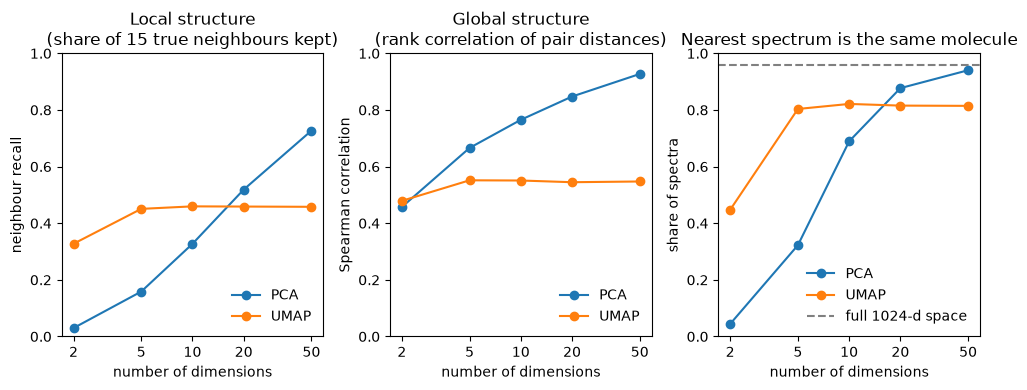

In [ ]:
fig, (ax_recall, ax_correlation, ax_molecule) = plt.subplots(1, 3, figsize=(10, 4))

ax_recall.plot(DIMENSIONS, scores["PCA"]["recall"], marker="o", color="tab:blue", label="PCA")
ax_recall.plot(DIMENSIONS, scores["UMAP"]["recall"], marker="o", color="tab:orange", label="UMAP")
ax_recall.set_title(f"Local structure\n(share of {N_NEIGHBOURS} true neighbours kept)")
ax_recall.set_ylabel("neighbour recall")

ax_correlation.plot(DIMENSIONS, scores["PCA"]["correlation"], marker="o", color="tab:blue", label="PCA")
ax_correlation.plot(DIMENSIONS, scores["UMAP"]["correlation"], marker="o", color="tab:orange", label="UMAP")
ax_correlation.set_title("Global structure\n(rank correlation of pair distances)")
ax_correlation.set_ylabel("Spearman correlation")

ax_molecule.plot(DIMENSIONS, scores["PCA"]["same_molecule"], marker="o", color="tab:blue", label="PCA")
ax_molecule.plot(DIMENSIONS, scores["UMAP"]["same_molecule"], marker="o", color="tab:orange", label="UMAP")
ax_molecule.axhline(full_space_same_molecule, color="grey", linestyle="--", label="full 1024-d space")
ax_molecule.set_title("Nearest spectrum is the same molecule")
ax_molecule.set_ylabel("share of spectra")

for ax in [ax_recall, ax_correlation, ax_molecule]:
    ax.set_xscale("log")
    ax.minorticks_off()
    ax.set_xticks(DIMENSIONS)
    ax.set_xticklabels(DIMENSIONS)
    ax.set_xlabel("number of dimensions")
    ax.set_ylim(0, 1)
    ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
save_figure(fig, "pca_vs_umap_scores")
plt.show()

## 4. 2D maps, PCA and UMAP side by side

What organizes the space? ~20k spectra projected to 2D, by PCA (first two components) and by UMAP (cosine metric, on the raw embeddings). Each row colours both maps the same way. If spectra group by how they were measured rather than by molecule, the embedding mixes measurement conditions into its notion of similarity.

Read UMAP maps for clusters only: distances between far-apart clusters are not meaningful (section 3, global structure).

In [ ]:
N_MAP = 20_000
N_HIGHLIGHT = 8

# enveda-180 molecules (the test-like library) with the most spectra, highlighted further down
spectra_per_molecule = (
    metadata
    .filter(pl.col("ingest_lib") == "enveda-180")
    .group_by("inchikey14")
    .len()
    .sort(["len", "inchikey14"], descending=[True, False])
)
highlight_keys = spectra_per_molecule["inchikey14"].head(N_HIGHLIGHT).to_list()
highlight_positions = metadata.filter(pl.col("inchikey14").is_in(highlight_keys))["position"].to_numpy()

# Random spectra, plus every spectrum of the highlighted molecules
random_positions = rng.choice(len(embeddings), size=N_MAP, replace=False)
map_positions = np.union1d(random_positions, highlight_positions)
map_metadata = metadata[map_positions.tolist()]
print(len(map_positions), "spectra on the maps")

# PCA map: first two components of the PCA fitted in section 3
pca_map = pca.transform(embeddings[map_positions])[:, :2]

# UMAP map: directly on the embeddings, with the cosine metric DreaMS was trained with
umap_map = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=0).fit_transform(embeddings[map_positions])

# Draw points in random order, so no category is always painted on top
draw_order = rng.permutation(len(map_positions))

20106 spectra on the maps


/Users/corentin_laudicina/Desktop/FILES/PROJECTS/Enveda CASMI 2026/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


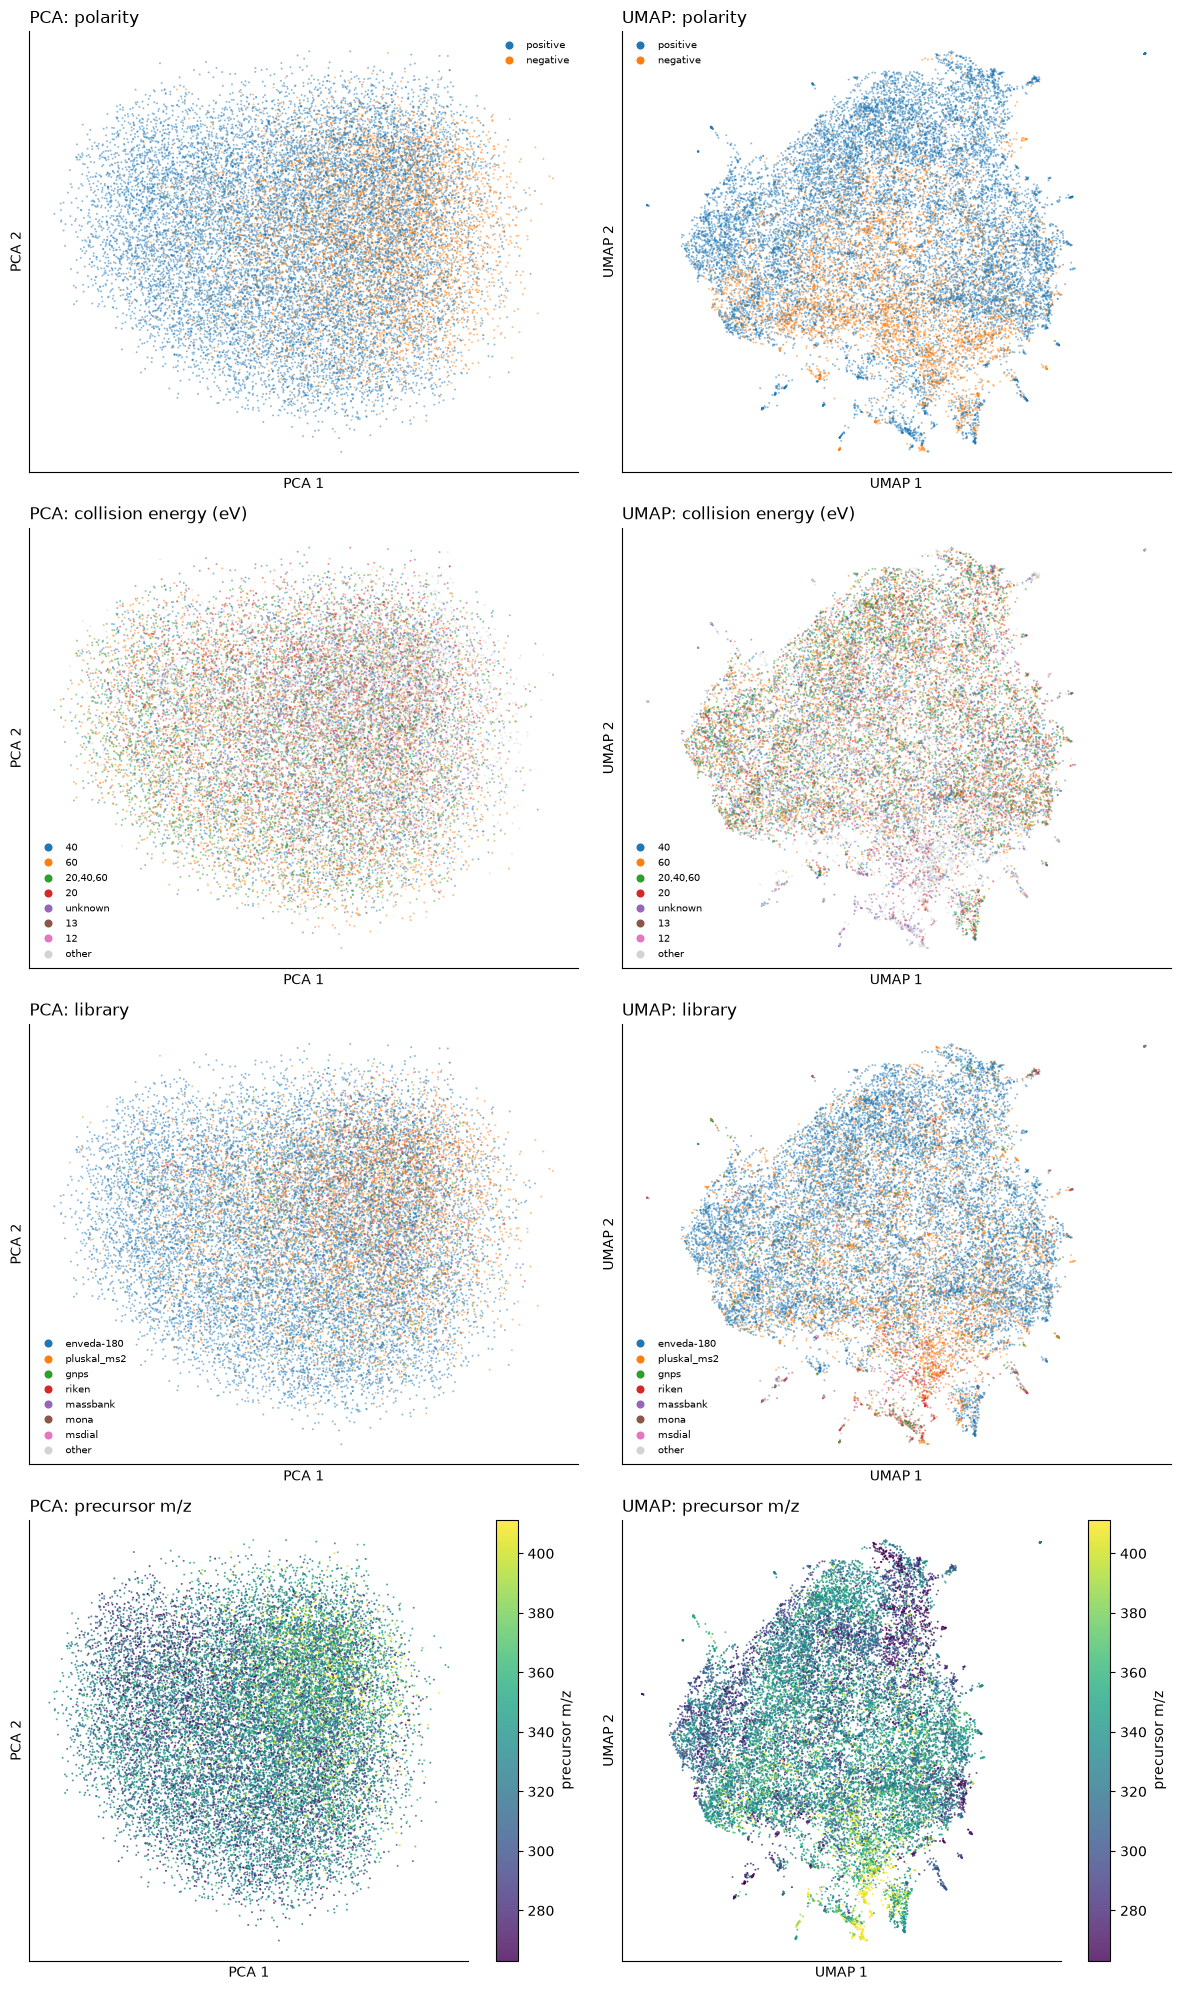

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(12, 20))

# Row 1: polarity
scatter_categories(axes[0, 0], pca_map, map_metadata["ionization_mode"], "PCA: polarity", draw_order)
scatter_categories(axes[0, 1], umap_map, map_metadata["ionization_mode"], "UMAP: polarity", draw_order)

# Row 2: collision energy
scatter_categories(axes[1, 0], pca_map, map_metadata["energy_label"], "PCA: collision energy (eV)", draw_order)
scatter_categories(axes[1, 1], umap_map, map_metadata["energy_label"], "UMAP: collision energy (eV)", draw_order)

# Row 3: library
scatter_categories(axes[2, 0], pca_map, map_metadata["ingest_lib"], "PCA: library", draw_order)
scatter_categories(axes[2, 1], umap_map, map_metadata["ingest_lib"], "UMAP: library", draw_order)

# Row 4: precursor m/z
masses = map_metadata["precursor_mz"].to_numpy()
scatter_mass(axes[3, 0], pca_map, masses, "PCA: precursor m/z", draw_order)
scatter_mass(axes[3, 1], umap_map, masses, "UMAP: precursor m/z", draw_order)

for row in range(4):
    clean_map_axis(axes[row, 0], "PCA")
    clean_map_axis(axes[row, 1], "UMAP")
fig.tight_layout()
save_figure(fig, "maps_pca_vs_umap")
plt.show()

The training sets include the spectra of molecules probed at different energies. Ideally, we would like the embeddings to be energy agnostic, so two spectra of one molecule at different energies should sit close to each other. Below, the spectra of the 8 `enveda-180` molecules with the most spectra: one colour per molecule, circles for positive mode, triangles for negative mode.

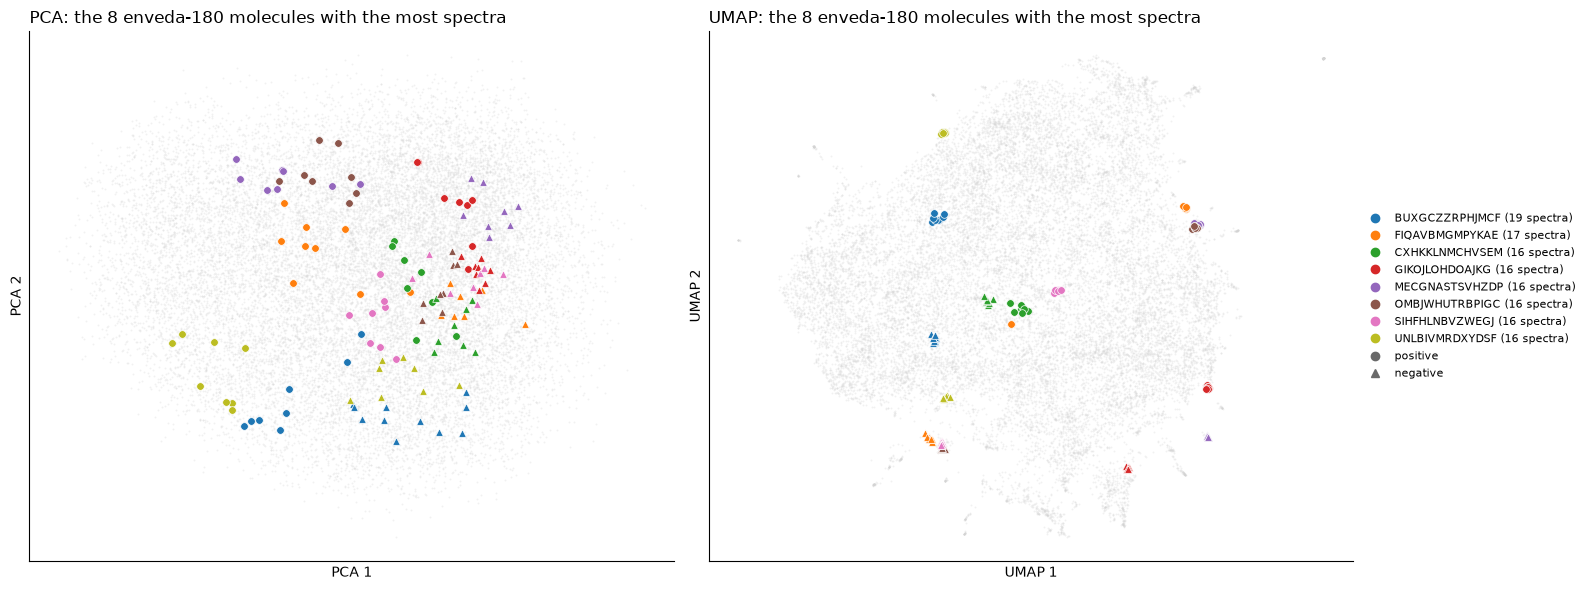

In [ ]:
POLARITY_MARKERS = {"positive": "o", "negative": "^"}


def plot_highlighted_molecules(ax, coords, axis_name):
    ax.scatter(coords[:, 0], coords[:, 1], c=OTHER_COLOR, s=2, alpha=0.3, linewidths=0)
    for index, key in enumerate(highlight_keys):
        is_molecule = (map_metadata["inchikey14"] == key).to_numpy()
        for polarity, marker in POLARITY_MARKERS.items():
            selected = is_molecule & (map_metadata["ionization_mode"] == polarity).to_numpy()
            ax.scatter(coords[selected, 0], coords[selected, 1], color=CATEGORY_COLORS[index],
                       marker=marker, s=30, edgecolors="white", linewidths=0.5)
    ax.set_title(f"{axis_name}: the {N_HIGHLIGHT} enveda-180 molecules with the most spectra", loc="left")
    clean_map_axis(ax, axis_name)


fig, (ax_pca, ax_umap) = plt.subplots(1, 2, figsize=(16, 6))
plot_highlighted_molecules(ax_pca, pca_map, "PCA")
plot_highlighted_molecules(ax_umap, umap_map, "UMAP")

handles = []
for index, key in enumerate(highlight_keys):
    n_spectra = int((map_metadata["inchikey14"] == key).sum())
    handles.append(Line2D([], [], marker="o", linestyle="", color=CATEGORY_COLORS[index], label=f"{key} ({n_spectra} spectra)"))
for polarity, marker in POLARITY_MARKERS.items():
    handles.append(Line2D([], [], marker=marker, linestyle="", color="dimgrey", label=polarity))
ax_umap.legend(handles=handles, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8, frameon=False)

fig.tight_layout()
save_figure(fig, "highlighted_molecules_pca_vs_umap")
plt.show()

## 5. Distances after reduction

The same pairs as in section 2, measured in the full space, after PCA (50 components) and after UMAP (2 dimensions, the map), all on the section-3 sample.

- **Euclidean distance** is defined in all three spaces. In UMAP it is only meaningful at short range, and spans several orders of magnitude, so that panel uses a log scale.
- **Angular distance** is defined for the full space and for PCA. PCA centres the data, so the angle there is measured around the **mean embedding**. It is **not defined for UMAP**: an angle is measured from the origin, and where UMAP puts its origin is arbitrary (shifting the whole map changes every angle without changing the map).

In [ ]:
PCA_DIMENSIONS = 50
UMAP_DIMENSIONS = 2

pca_coords = reduced_coords["PCA"][PCA_DIMENSIONS]
umap_coords = reduced_coords["UMAP"][UMAP_DIMENSIONS]

# All pairs of spectra of the same molecule within the sample, split by polarity
compare_polarities = polarities[compare_positions]
same_first = []
same_second = []
opposite_first = []
opposite_second = []
for key in np.unique(compare_keys):
    indices = np.flatnonzero(compare_keys == key)
    first_in_pair, second_in_pair = np.triu_indices(len(indices), k=1)
    for a, b in zip(indices[first_in_pair], indices[second_in_pair]):
        if compare_polarities[a] == compare_polarities[b]:
            same_first.append(a)
            same_second.append(b)
        else:
            opposite_first.append(a)
            opposite_second.append(b)
same_first = np.array(same_first)
same_second = np.array(same_second)
opposite_first = np.array(opposite_first)
opposite_second = np.array(opposite_second)

# Random pairs of different molecules within the sample
pair_first = rng.integers(0, len(compare_positions), N_CORRELATION_PAIRS)
pair_second = rng.integers(0, len(compare_positions), N_CORRELATION_PAIRS)
different = compare_keys[pair_first] != compare_keys[pair_second]
pair_first = pair_first[different]
pair_second = pair_second[different]

print(f"{len(same_first):,} same-polarity pairs, {len(opposite_first):,} opposite-polarity pairs, "
      f"{len(pair_first):,} random pairs")

22,013 same-polarity pairs, 11,684 opposite-polarity pairs, 49,970 random pairs


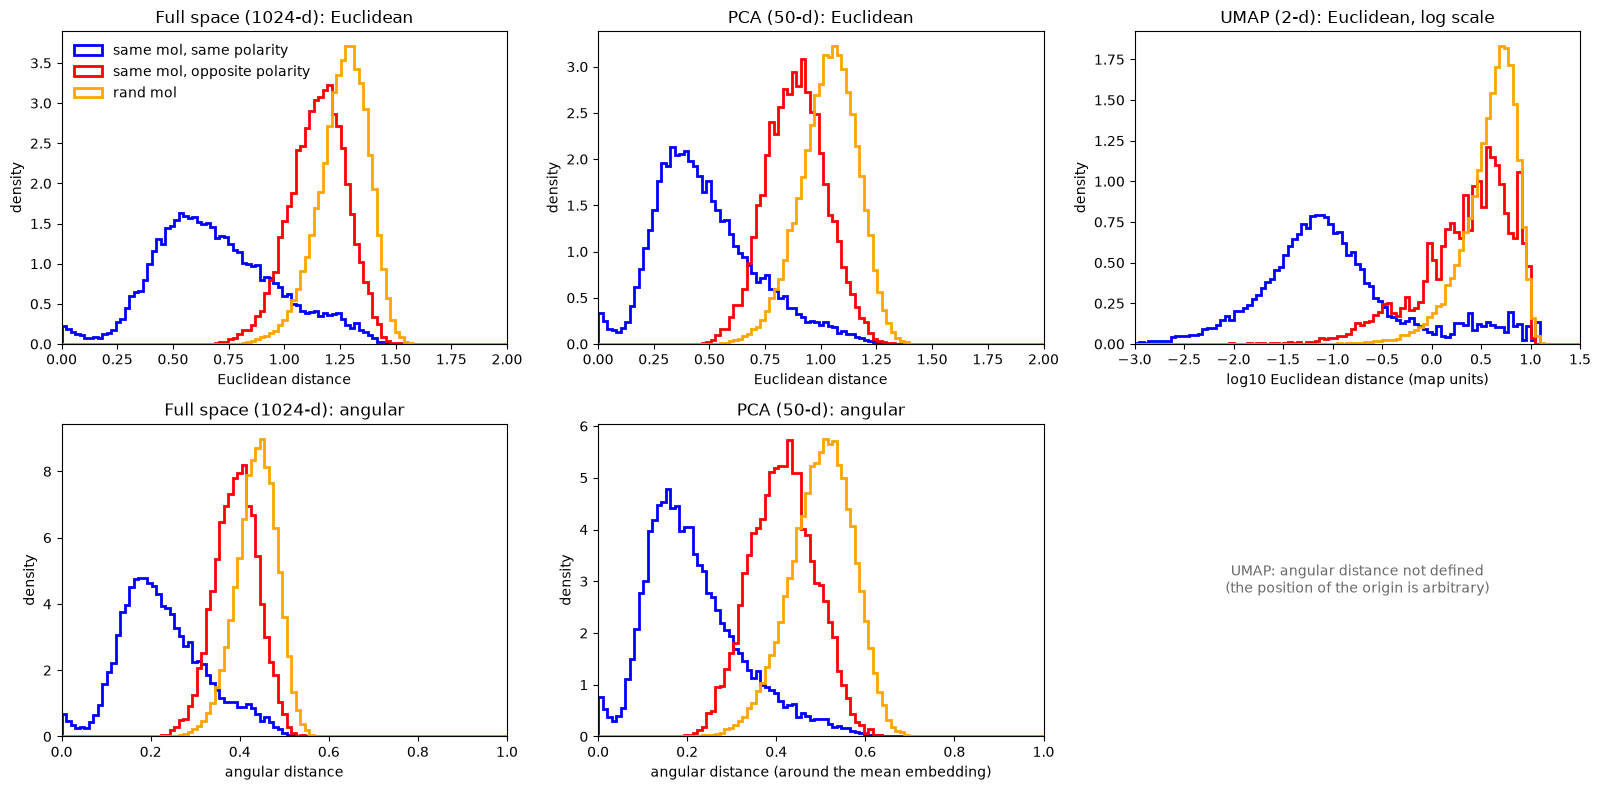

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Top row: Euclidean distance in the three spaces
plot_pair_distances(
    axes[0, 0],
    euclidean_between(compare_embeddings, same_first, same_second),
    euclidean_between(compare_embeddings, opposite_first, opposite_second),
    euclidean_between(compare_embeddings, pair_first, pair_second),
    bins=np.linspace(0, 2, 100),
    xlabel="Euclidean distance",
    title="Full space (1024-d): Euclidean",
    legend=True,
)
plot_pair_distances(
    axes[0, 1],
    euclidean_between(pca_coords, same_first, same_second),
    euclidean_between(pca_coords, opposite_first, opposite_second),
    euclidean_between(pca_coords, pair_first, pair_second),
    bins=np.linspace(0, 2, 100),
    xlabel="Euclidean distance",
    title=f"PCA ({PCA_DIMENSIONS}-d): Euclidean",
)
# UMAP distances span several orders of magnitude (same molecule ~0.05, random pairs ~5),
# so this panel shows log10 of the distance
plot_pair_distances(
    axes[0, 2],
    np.log10(euclidean_between(umap_coords, same_first, same_second)),
    np.log10(euclidean_between(umap_coords, opposite_first, opposite_second)),
    np.log10(euclidean_between(umap_coords, pair_first, pair_second)),
    bins=np.linspace(-3, 1.5, 100),
    xlabel="log10 Euclidean distance (map units)",
    title=f"UMAP ({UMAP_DIMENSIONS}-d): Euclidean, log scale",
)

# Bottom row: angular distance (not defined for UMAP)
plot_pair_distances(
    axes[1, 0],
    angular_between(compare_embeddings, same_first, same_second),
    angular_between(compare_embeddings, opposite_first, opposite_second),
    angular_between(compare_embeddings, pair_first, pair_second),
    bins=np.linspace(0, 1, 100),
    xlabel="angular distance",
    title="Full space (1024-d): angular",
)
plot_pair_distances(
    axes[1, 1],
    angular_between(pca_coords, same_first, same_second),
    angular_between(pca_coords, opposite_first, opposite_second),
    angular_between(pca_coords, pair_first, pair_second),
    bins=np.linspace(0, 1, 100),
    xlabel="angular distance (around the mean embedding)",
    title=f"PCA ({PCA_DIMENSIONS}-d): angular",
)
axes[1, 2].axis("off")
axes[1, 2].text(0.5, 0.5, "UMAP: angular distance not defined\n(the position of the origin is arbitrary)",
                ha="center", va="center", color="dimgrey")

fig.tight_layout()
save_figure(fig, "distances_after_reduction")
plt.show()

## 6. The isomer test

Ranking candidates means choosing among **isomers**: different molecules with the same formula, hence the same mass. Can DreaMS tell a molecule's own spectra from its isomers' spectra?

We take every group of spectra sharing a formula and a polarity that contains at least two different molecules (polarity is fixed, because the ranking never compares across polarities). Within each group:
1. **Distributions**: angular distance for pairs of the same molecule vs pairs of isomers. Random pairs of the same polarity are the reference.
2. **AUC**: probability that a same-molecule pair is closer than an isomer pair (0.5 = no separation, 1 = perfect). Split by adduct and collision energy: "same molecule, same adduct, at a different energy vs isomer at the same adduct and energy" is the realistic case for library search.
3. **Ranking**: for each spectrum, is its closest spectrum in the group one of its own molecule? This is top-1 accuracy among isomers, compared with picking at random. A stricter version counts only the molecule's spectra at a **different** collision energy, so that near-identical replicates at the same energy cannot help.

In [ ]:
from sklearn.metrics import roc_auc_score

# Groups of spectra sharing a formula and a polarity, with at least two different molecules
isomer_groups = (
    metadata
    .group_by("molecular_formula", "ionization_mode")
    .agg(pl.col("position"), n_molecules=pl.col("inchikey14").n_unique())
    .filter(pl.col("n_molecules") >= 2)
)
print(f"{isomer_groups.height} groups, {isomer_groups['position'].list.len().sum():,} spectra")

energy_labels = metadata["energy_label"].fill_null("unknown").to_numpy()
adducts = metadata["adduct"].to_numpy()

# Per pair: angular distance, same molecule or isomer, same or different collision energy
pair_distances_list = []
pair_same_molecule_list = []
pair_same_energy_list = []
pair_different_energy_list = []
pair_same_adduct_list = []

# Per spectrum: is the closest other spectrum in the group from its own molecule?
own_is_closest = []
chance_own_is_closest = []
isomers_in_group = []
# Stricter: only the molecule's spectra at a different collision energy count as "own"
own_other_energy_is_closest = []
chance_own_other_energy_is_closest = []

for positions, n_molecules in zip(isomer_groups["position"], isomer_groups["n_molecules"]):
    positions = positions.to_numpy()
    group_keys = keys[positions]
    group_energies = energy_labels[positions]
    group_adducts = adducts[positions]
    similarities = embeddings[positions] @ embeddings[positions].T

    # Every pair in the group once
    first_in_pair, second_in_pair = np.triu_indices(len(positions), k=1)
    both_energies_known = (group_energies[first_in_pair] != "unknown") & (group_energies[second_in_pair] != "unknown")
    same_energy_label = group_energies[first_in_pair] == group_energies[second_in_pair]
    pair_distances_list.append(angular_distance(similarities[first_in_pair, second_in_pair]))
    pair_same_molecule_list.append(group_keys[first_in_pair] == group_keys[second_in_pair])
    pair_same_energy_list.append(both_energies_known & same_energy_label)
    pair_different_energy_list.append(both_energies_known & ~same_energy_label)
    pair_same_adduct_list.append(group_adducts[first_in_pair] == group_adducts[second_in_pair])

    # Ranking: compare each spectrum's best match among its own molecule vs among the isomers
    np.fill_diagonal(similarities, -np.inf)  # a spectrum never matches itself
    for index in range(len(positions)):
        is_own = group_keys == group_keys[index]
        is_own[index] = False
        n_own = int(is_own.sum())
        if n_own == 0:
            continue  # no other spectrum of this molecule to find
        best_own = similarities[index, is_own].max()
        best_isomer = similarities[index, ~is_own].max()
        own_is_closest.append(best_own > best_isomer)
        chance_own_is_closest.append(n_own / (len(positions) - 1))
        isomers_in_group.append(n_molecules - 1)

        # Stricter version: drop the molecule's spectra at the same energy (and unknown energies)
        known_other_energy = (group_energies != group_energies[index]) & (group_energies != "unknown")
        is_own_other_energy = is_own & known_other_energy
        n_own_other_energy = int(is_own_other_energy.sum())
        if group_energies[index] != "unknown" and n_own_other_energy > 0:
            best_own_other_energy = similarities[index, is_own_other_energy].max()
            own_other_energy_is_closest.append(best_own_other_energy > best_isomer)
            n_candidates = n_own_other_energy + int((~is_own).sum()) - 1  # minus the spectrum itself
            chance_own_other_energy_is_closest.append(n_own_other_energy / n_candidates)

pair_distances = np.concatenate(pair_distances_list)
pair_same_molecule = np.concatenate(pair_same_molecule_list)
pair_same_energy = np.concatenate(pair_same_energy_list)
pair_different_energy = np.concatenate(pair_different_energy_list)
pair_same_adduct = np.concatenate(pair_same_adduct_list)
own_is_closest = np.array(own_is_closest)
chance_own_is_closest = np.array(chance_own_is_closest)
isomers_in_group = np.array(isomers_in_group)
own_other_energy_is_closest = np.array(own_other_energy_is_closest)
chance_own_other_energy_is_closest = np.array(chance_own_other_energy_is_closest)

# Reference: random pairs of different molecules with the same polarity (from section 2)
random_same_polarity = polarities[random_first] == polarities[random_second]
random_same_polarity_distances = angular_distance(random_similarities[random_same_polarity])

same_molecule_distances = pair_distances[pair_same_molecule]
isomer_distances = pair_distances[~pair_same_molecule]
print(f"{len(same_molecule_distances):,} same-molecule pairs, {len(isomer_distances):,} isomer pairs, "
      f"{len(own_is_closest):,} spectra ranked")

1352 groups, 117,693 spectra
598,279 same-molecule pairs, 22,397,949 isomer pairs, 116,433 spectra ranked


In [ ]:
def separation_auc(same_molecule, other):
    """Probability that a same-molecule pair is closer than a pair from `other` (closer = higher score)."""
    labels = np.concatenate([np.ones(len(same_molecule)), np.zeros(len(other))])
    scores = -np.concatenate([same_molecule, other])
    return roc_auc_score(labels, scores)


# Same-molecule pairs, by adduct and energy
same_molecule_same_setup = pair_distances[pair_same_molecule & pair_same_adduct & pair_same_energy]
same_molecule_other_energy = pair_distances[pair_same_molecule & pair_same_adduct & pair_different_energy]
same_molecule_other_adduct = pair_distances[pair_same_molecule & ~pair_same_adduct]

# Isomer pairs measured with the same adduct and energy: the competitors in a library search
isomer_same_setup = pair_distances[~pair_same_molecule & pair_same_adduct & pair_same_energy]

auc_rows = [
    ("same molecule vs random molecule", separation_auc(same_molecule_distances, random_same_polarity_distances)),
    ("same molecule vs isomer", separation_auc(same_molecule_distances, isomer_distances)),
    ("same molecule, same adduct & energy vs isomer, same adduct & energy",
     separation_auc(same_molecule_same_setup, isomer_same_setup)),
    ("same molecule, same adduct, other energy vs isomer, same adduct & energy",
     separation_auc(same_molecule_other_energy, isomer_same_setup)),
    ("same molecule, other adduct vs isomer, same adduct & energy",
     separation_auc(same_molecule_other_adduct, isomer_same_setup)),
]
for name, auc in auc_rows:
    print(f"{name:<74} AUC {auc:.3f}")

print()
print(f"closest spectrum is its own molecule: {own_is_closest.mean():.1%} "
      f"(random guess: {chance_own_is_closest.mean():.1%}, {len(own_is_closest):,} spectra)")
print(f"same, counting only its spectra at another energy: {own_other_energy_is_closest.mean():.1%} "
      f"(random guess: {chance_own_other_energy_is_closest.mean():.1%}, {len(own_other_energy_is_closest):,} spectra)")

same molecule vs random molecule                                           AUC 0.890
same molecule vs isomer                                                    AUC 0.762
same molecule, same adduct & energy vs isomer, same adduct & energy        AUC 0.902
same molecule, same adduct, other energy vs isomer, same adduct & energy   AUC 0.834
same molecule, other adduct vs isomer, same adduct & energy                AUC 0.313

closest spectrum is its own molecule: 88.6% (random guess: 7.6%, 116,433 spectra)
same, counting only its spectra at another energy: 87.7% (random guess: 6.4%, 111,990 spectra)


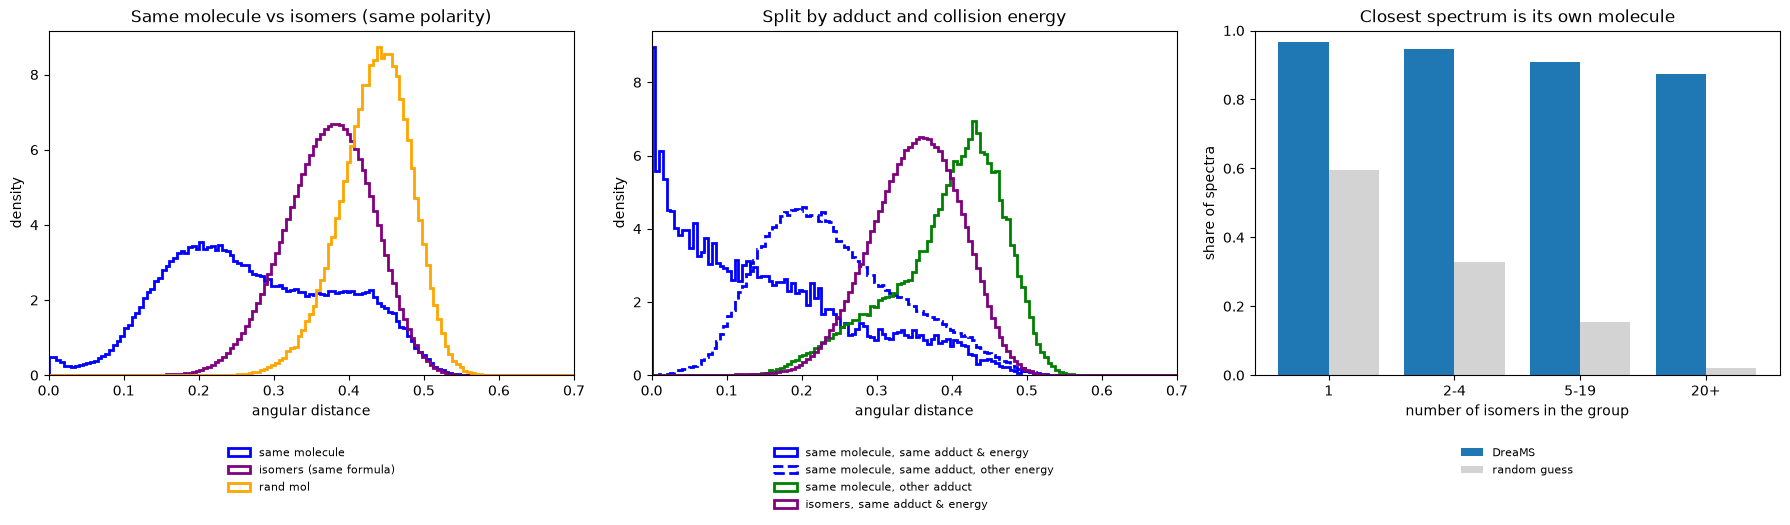

In [ ]:
fig, (ax_distributions, ax_setup, ax_ranking) = plt.subplots(1, 3, figsize=(18, 5.5))

# Left: same molecule vs isomers vs random molecules
bins = np.linspace(0, 1, 200)
ax_distributions.hist(same_molecule_distances, bins=bins, density=True, histtype="step", linewidth=2,
                      color="blue", label="same molecule")
ax_distributions.hist(isomer_distances, bins=bins, density=True, histtype="step", linewidth=2,
                      color="purple", label="isomers (same formula)")
ax_distributions.hist(random_same_polarity_distances, bins=bins, density=True, histtype="step", linewidth=2,
                      color="orange", label="rand mol")
ax_distributions.set_xlim(0, 0.7)
ax_distributions.set_xlabel("angular distance")
ax_distributions.set_ylabel("density")
ax_distributions.set_title("Same molecule vs isomers (same polarity)")
ax_distributions.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.18), fontsize=8)

# Middle: what separates a molecule's own spectra from its isomers
ax_setup.hist(same_molecule_same_setup, bins=bins, density=True, histtype="step", linewidth=2,
              color="blue", label="same molecule, same adduct & energy")
ax_setup.hist(same_molecule_other_energy, bins=bins, density=True, histtype="step", linewidth=2,
              color="blue", linestyle="--", label="same molecule, same adduct, other energy")
ax_setup.hist(same_molecule_other_adduct, bins=bins, density=True, histtype="step", linewidth=2,
              color="green", label="same molecule, other adduct")
ax_setup.hist(isomer_same_setup, bins=bins, density=True, histtype="step", linewidth=2,
              color="purple", label="isomers, same adduct & energy")
ax_setup.set_xlim(0, 0.7)
ax_setup.set_xlabel("angular distance")
ax_setup.set_ylabel("density")
ax_setup.set_title("Split by adduct and collision energy")
ax_setup.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.18), fontsize=8)

# Right: top-1 accuracy among isomers, by number of isomers in the group
size_bins = [(1, 1), (2, 4), (5, 19), (20, 10_000)]
size_labels = ["1", "2-4", "5-19", "20+"]
accuracies = []
chances = []
for low, high in size_bins:
    in_bin = (isomers_in_group >= low) & (isomers_in_group <= high)
    accuracies.append(own_is_closest[in_bin].mean())
    chances.append(chance_own_is_closest[in_bin].mean())
x = np.arange(len(size_bins))
ax_ranking.bar(x - 0.2, accuracies, width=0.4, color="tab:blue", label="DreaMS")
ax_ranking.bar(x + 0.2, chances, width=0.4, color="lightgrey", label="random guess")
ax_ranking.set_xticks(x)
ax_ranking.set_xticklabels(size_labels)
ax_ranking.set_xlabel("number of isomers in the group")
ax_ranking.set_ylabel("share of spectra")
ax_ranking.set_ylim(0, 1)
ax_ranking.set_title("Closest spectrum is its own molecule")
ax_ranking.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.18), fontsize=8)

fig.tight_layout()
save_figure(fig, "isomer_test")
plt.show()

### Same molecule, different adducts

The AUC of 0.313 above says that a molecule's spectra measured with another adduct sit *further* from it than its isomers measured with the same adduct. Below, the median angular distance between pairs of spectra of the same molecule, by adduct pair (all 121k embedded spectra, at most 100 spectra per molecule). Reference: **0.44** for random pairs of different molecules with the same polarity.

| Pair type | Median | What it means |
|---|---|---|
| Same adduct: `[M+H]+`/`[M+H]+`, `[M-H]-`/`[M-H]-`, NH4/NH4, K/K | 0.19–0.22 | Tight: same molecule, close together |
| `[M+Na]+` / `[M+Na]+` | 0.35 | Loose even with the same adduct |
| `[M-H]-` / `[M+CH2O2-H]-` (formate) | 0.29 | Closest cross-adduct pair |
| `[M-H]-` / `[M+Cl]-` | 0.34 | |
| `[M+Na]+` / `[M+K]+` | 0.37 | |
| `[M+H]+` / `[M+NH4]+` | 0.38 | Wide spread (0.30–0.43) |
| `[M+H]+` / `[M+Na]+` | **0.43** | About the same as a random different molecule |
| Opposite polarity (e.g. `[M+H]+` / `[M-H]-`) | 0.39–0.43 | Near random |

**Interpretation** (chemical reasoning, not tested here):
- **Adducts that fall back to the base ion end up close.** Formate and chloride adducts mostly lose HCOOH or HCl in the collision cell, which leaves `[M-H]-`, and that ion then fragments as usual. `[M+NH4]+` often loses NH3 and becomes `[M+H]+`, but not always, hence its wide spread.
- **Metal adducts fragment differently.** In `[M+H]+` the proton can move around the molecule and drives the cleavages. Na+ and K+ stay fixed where they bind, so the molecule breaks along different bonds. The fragments that keep the metal are also shifted by +22 (Na) or +38 (K) compared with protonated ones, and many spectra have only a few peaks besides the precursor. This would explain why `[M+Na]+` vs `[M+H]+` looks like a different molecule, why Na vs K is moderately close, and why Na/Na pairs are noisy.
- **DreaMS compares fragment patterns, not chemistry.** If the peaks don't line up, the embeddings don't either. It was also pretrained mostly on positive-mode, protonated spectra, so it has little reason to map `[M+Na]+` near `[M+H]+`.

**For ranking:** use embedding distance only between spectra with the same adduct (and polarity). A reference spectrum of the right molecule with a different adduct is about as useful as no reference at all. `[M+H]+` and `[M-H]-` make up 90% of the spectra, so this mostly affects the long tail.